# Évaluation du modèle sur les données de test

Ce notebook charge le meilleur modèle issu de `Train.ipynb` et évalue ses performances sur le dataset de test nettoyé par `Data-cleaning.ipynb`.

**Prérequis** : avoir exécuté `Train.ipynb` (génère `best_model.pkl` et `preprocessor.pkl`) et `Data-cleaning.ipynb` (génère `wind_turbine_maintenance_test_data_cleaned.csv`).

In [11]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

## Chargement du modèle et du preprocesseur

In [12]:
model       = joblib.load("../models/best_model.pkl")
preprocessor = joblib.load("../models/preprocessor.pkl")

print(f"Modele chargé       : {type(model).__name__}")
print(f"Parametres          : {model.get_params()}")

Modele chargé       : RandomForestClassifier
Parametres          : {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}


## Chargement des données de test nettoyées

In [13]:
df_test = pd.read_csv("../data/processed/wind_turbine_maintenance_test_data_cleaned.csv")

print(f"Dimensions : {df_test.shape}")
display(df_test.head())

print(f"\nDistribution des labels :")
print(df_test["Maintenance_Label"].value_counts())

Dimensions : (17520, 7)


,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Maintenance_Label
0,16.329212,7.229967,1468.371964,60.045948,69.645919,1.712257,2
1,14.109988,8.943831,1793.460409,58.544454,74.709346,2.117721,0
2,16.259475,9.562434,1492.022307,57.223514,77.115291,2.075517,0
3,13.420109,6.911183,1514.954999,57.041996,80.484269,1.849384,0
4,16.428984,5.910646,1487.018006,68.157615,72.067310,2.058144,0



Distribution des labels :
Maintenance_Label
0    14782
1     1386
2     1352
Name: count, dtype: int64


## Séparation features / cible

In [14]:
X_test = df_test.drop("Maintenance_Label", axis=1)
Y_test = df_test["Maintenance_Label"]

print(f"X_test : {X_test.shape}")
print(f"Y_test : {Y_test.shape}")

X_test : (17520, 6)
Y_test : (17520,)


## Preprocessing

On applique le `transform` (sans re-fit) du preprocesseur entraîné sur les données d'apprentissage.

In [15]:
X_test_processed = preprocessor.transform(X_test)
print(f"X_test après preprocessing : {X_test_processed.shape}")

X_test après preprocessing : (17520, 6)


## Prédictions

In [16]:
Y_pred = model.predict(X_test_processed)

print(f"Prédictions — distribution :")
unique, counts = np.unique(Y_pred, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Label {label} : {count} ({count/len(Y_pred)*100:.1f}%)")

Prédictions — distribution :
  Label 0 : 14569 (83.2%)
  Label 1 : 1375 (7.8%)
  Label 2 : 1576 (9.0%)


## Évaluation des performances

In [17]:
acc    = accuracy_score(Y_test, Y_pred)
f1_mac = f1_score(Y_test, Y_pred, average="macro",    zero_division=0)
f1_w   = f1_score(Y_test, Y_pred, average="weighted", zero_division=0)

print("=" * 55)
print(f"Accuracy            : {acc:.4f}")
print(f"F1-Score macro      : {f1_mac:.4f}")
print(f"F1-Score weighted   : {f1_w:.4f}")
print("=" * 55)
print()
print("Rapport de classification :")
print(classification_report(
    Y_test, Y_pred,
    target_names=["Pas de maintenance", "Maint. mineure", "Maint. majeure"],
    zero_division=0
))

Accuracy            : 0.7136
F1-Score macro      : 0.3315
F1-Score weighted   : 0.7182

Rapport de classification :
                    precision    recall  f1-score   support

Pas de maintenance       0.84      0.83      0.84     14782
    Maint. mineure       0.09      0.09      0.09      1386
    Maint. majeure       0.07      0.08      0.07      1352

          accuracy                           0.71     17520
         macro avg       0.33      0.33      0.33     17520
      weighted avg       0.72      0.71      0.72     17520



## Matrice de confusion

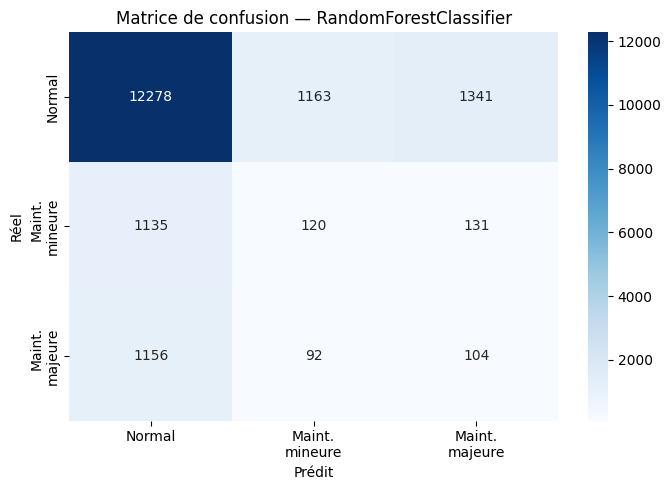

In [18]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Maint.\nmineure", "Maint.\nmajeure"],
            yticklabels=["Normal", "Maint.\nmineure", "Maint.\nmajeure"])
plt.title(f"Matrice de confusion — {type(model).__name__}")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.show()

## Conclusion

Ce notebook permet de vérifier que le modèle généralise bien sur des données qu'il n'a jamais vues. Un F1 macro proche de celui obtenu sur le jeu de validation dans `Train.ipynb` confirme qu'il n'y a pas de surapprentissage significatif.